In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
import astroML.stats
from numpy.random import choice


In [2]:
def probability(tomorrow,today):
    if (today==0) & (tomorrow==0): return 0.5
    elif (today==0) & (tomorrow==1): return 0.5
    elif (today==1) & (tomorrow==0): return 0.1
    elif (today==1) & (tomorrow==1): return 0.9
        
# Ex.
# tomorrow cloudy, today cloudy: 0,0
# tomorrow clear, today cloudy: 1,0

def jump(today):
    if (today==0):
        draw = choice([0,1],1,p=[probability(0,today),probability(1,today)],replace=False)
        
    else: 
        draw = choice([0,1],1,p=[probability(0,today),probability(1,today)],replace=False)

    return draw[0]
def jump(today):
    if (today==0):
        draw = choice([0,1],1,p=[0.5,0.5],replace=False)
        
    elif (today==1): 
        draw = choice([0,1],1,p=[0.1,0.9],replace=False)

    return draw[0]

In [3]:
N=100000
p_init = 1
p_current = p_init
posterior = [p_current]
clear_counter=[p_init]
cloudy_counter=[p_init]



for i in range(N):
    p_current = jump(p_current)
    posterior = np.append(posterior,p_current)
    clear_counter = np.append(clear_counter,posterior.sum())
    cloudy_counter = np.append(cloudy_counter,posterior.sum())


In [4]:
burn_in = 2000

In [5]:
import astroML

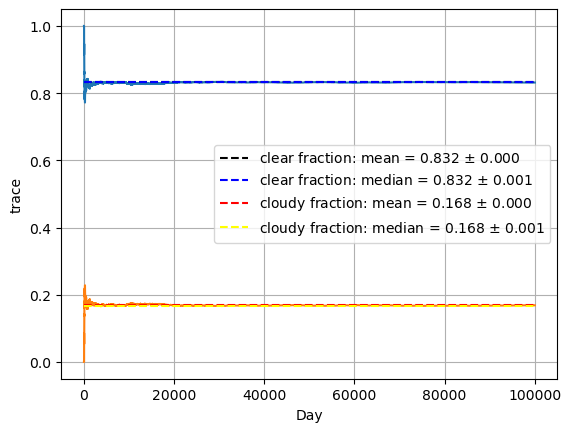

In [6]:
freq_clear = clear_counter/np.arange(1,N+2)
freq_cloudy = cloudy_counter/np.arange(1,N+2)

plt.plot(np.arange(1,N+2),freq_clear)
plt.plot(np.arange(1,N+2),1-freq_clear)
plt.xlabel('Day')
plt.ylabel('trace')
plt.hlines(np.mean(freq_clear[burn_in:]),0,N,linestyle='--',color='k', label= r'clear fraction: mean = %.3f $\pm$ %.3f' % (np.mean(freq_clear[burn_in:]), np.std(freq_clear[burn_in:])/(len((freq_clear[burn_in:])-1))))
plt.hlines(np.median(freq_clear[burn_in:]),0,N,linestyle='--',color='b', label= r'clear fraction: median = %.3f $\pm$ %.3f' % (np.median(freq_clear[burn_in:]), astroML.stats.sigmaG(freq_clear[burn_in:])))
plt.hlines(np.mean(1-freq_clear[burn_in:]),0,N,linestyle='--',color='r', label= 'cloudy fraction: mean = %.3f $\pm$ %.3f' % (np.mean(1-freq_clear[burn_in:]), np.std(1-freq_clear[burn_in:])/(len((1-freq_clear[burn_in:])-1))))
plt.hlines(np.median(1-freq_clear[burn_in:]),0,N,linestyle='--',color='yellow', label= 'cloudy fraction: median = %.3f $\pm$ %.3f' % (np.median(1-freq_clear[burn_in:]), astroML.stats.sigmaG(1-freq_clear[burn_in:])))
plt.grid()
plt.legend()

In [7]:
print('mean: %.5f +/-%.5f' % (np.mean(freq_clear[burn_in:]), np.std(freq_clear[burn_in:])/np.sqrt(len(freq_clear[burn_in:]))))
print('median: %5f +/- %5f' % (np.median(freq_clear[burn_in:]), astroML.stats.sigmaG(freq_clear[burn_in:])))

mean: 0.83169 +/-0.00000
median: 0.832127 +/- 0.000818


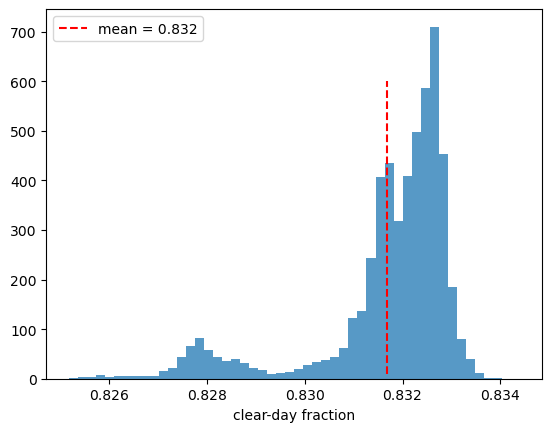

In [8]:
plt.hist(freq_clear[burn_in:],50,alpha=0.75,density=True)
plt.vlines(np.mean(freq_clear[burn_in:]),10,600,linestyle='--',color='r',label='mean = %.3f' % np.mean(freq_clear[burn_in:]))
plt.legend()
plt.xlabel('clear-day fraction');

In [9]:
burnins = np.arange((0),(40000), 5000)
burnins

array([    0,  5000, 10000, 15000, 20000, 25000, 30000, 35000])

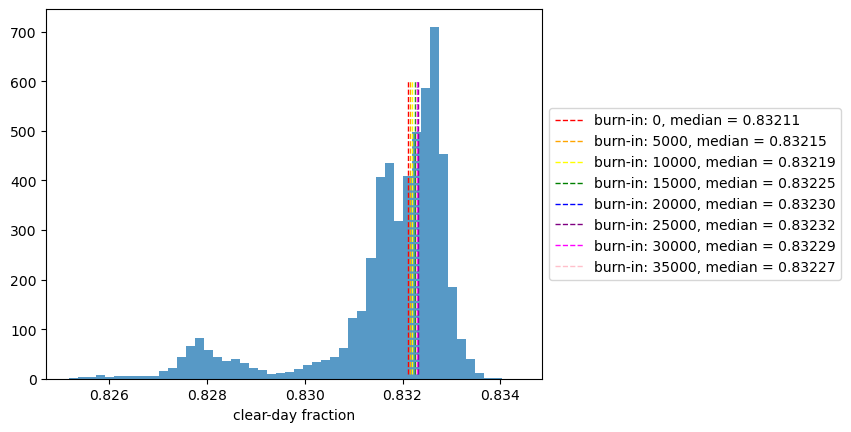

In [10]:
plt.hist(freq_clear[burn_in:],50,alpha=0.75,density=True)
c = ['r','orange','yellow','g','blue','purple','magenta','pink','r']
for i,burnin in zip(range(len(burnins)), burnins):
    plt.vlines(np.median(freq_clear[burnin:]),10,600,ls='--',lw=1,color=c[i],label='burn-in: %d, median = %.5f' % (burnin,np.median(freq_clear[burnin:])))
plt.legend(bbox_to_anchor=(1.0, 0.5), loc="center left")
plt.xlabel('clear-day fraction');

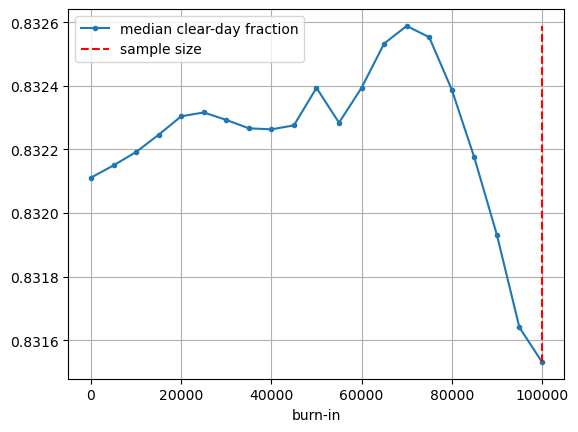

In [11]:
burnins = np.arange((0),(105000), 5000)
medians = []
for burnin in burnins: medians.append(np.median(freq_clear[burnin:]))
plt.plot(burnins,medians,marker='.',label='median clear-day fraction')
plt.vlines(N,min(medians),max(medians),color='r',ls='--',label='sample size')
plt.xlabel('burn-in')
plt.legend()
plt.grid();